In [1]:
!pip install pycryptodome


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 16.0 MB/s eta 0:00:00


Original Message: i am varshini
Encrypted Message: b'\t\xca\xad"ox~\xc2\xa8Eue]\xe5\x0e\xa6(\xe1\x1b\n\xa5c\x7f\xdds\\n\x92\xdd\x8c4\xe6\xb2\x85\xbcP\x1f\x80b\x08!\xc4;\xf3$\xa6NR\x03j\x08U\xa1\xe8\x19!Y\xecb\xd0\x1dS*\x1b\x0f\xa8\x92\x06\xbaq\xe9\xf5O[\x9b\xdf\xfdJ\t\x8d\x1f\xe8\xa7\xc2H\xb5vx[l\xbc|tp\x90c\xb5\xa8Q\xa4D\xe8\xda<\x0b\x9c\xbfV\x10\xdb\xff\xb8\xed\x96\xbf\r\x9b\x95Ee\xab\x9b\t\x03w\xce\x8f\xe9\xc1\x18\xe7\xe4B\x8d\x84-pN6\r\x90#At\x16\xb6\xcflI\x8d\\,\x1b\x17qL\xa5|\xa9\xc6\xc4\x80\xa8\xb0\x92\xa3\x7fM\x9br\xe1\x06\xf1~\xde\x94\xaf\x01\xb4\xba[$<Z\xc3\x84\xf3u\x17\r\xab;\x8aC\xa0\xe5\xa1\xa9$\xf0\xac\xd5\xbby\x93\x10\xc1{\x02\xe4\xef0\xf5*[++\xcb\xebP\x81N\xb8\xb3\xe3xNj\x8ao\x0e\xae&\xeb\x98&p\xc2\xe9\x92\xe0\xcc\x08P\xdf\xdc\xd5\xcb\x7fA\x88N\x81\x06Uy'
Decrypted Message: i am varshini


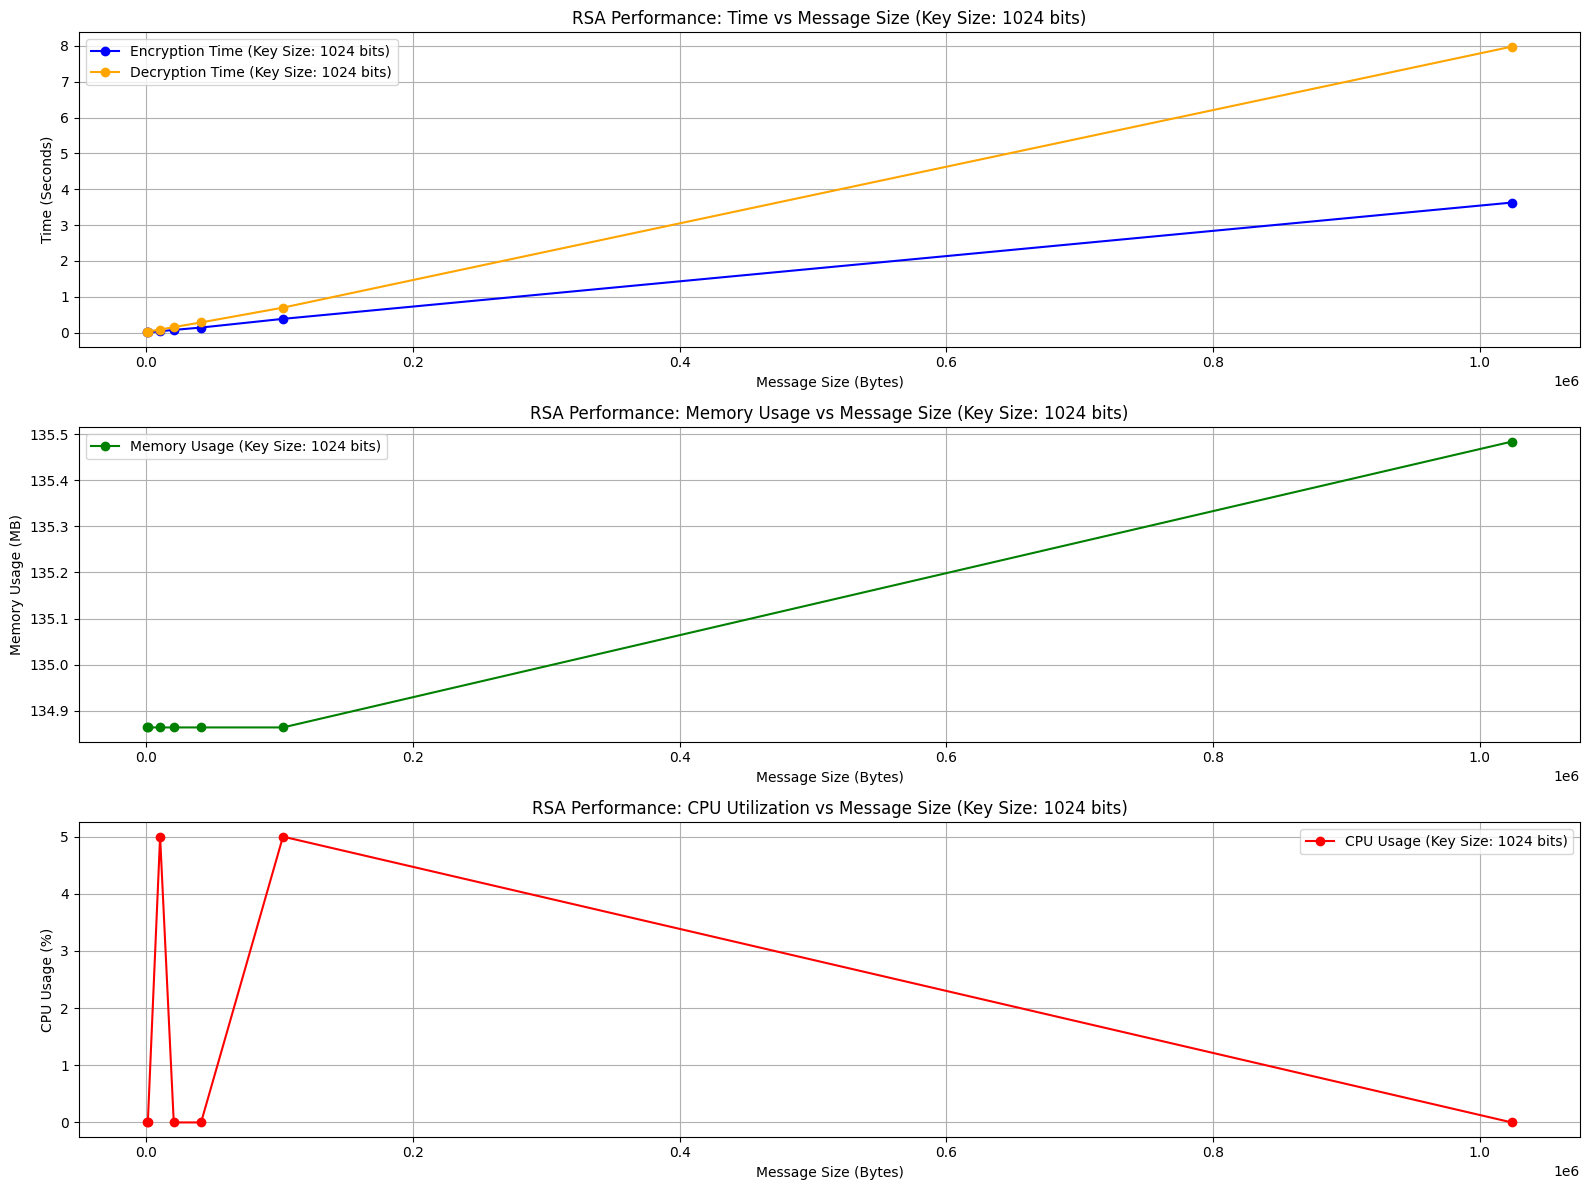

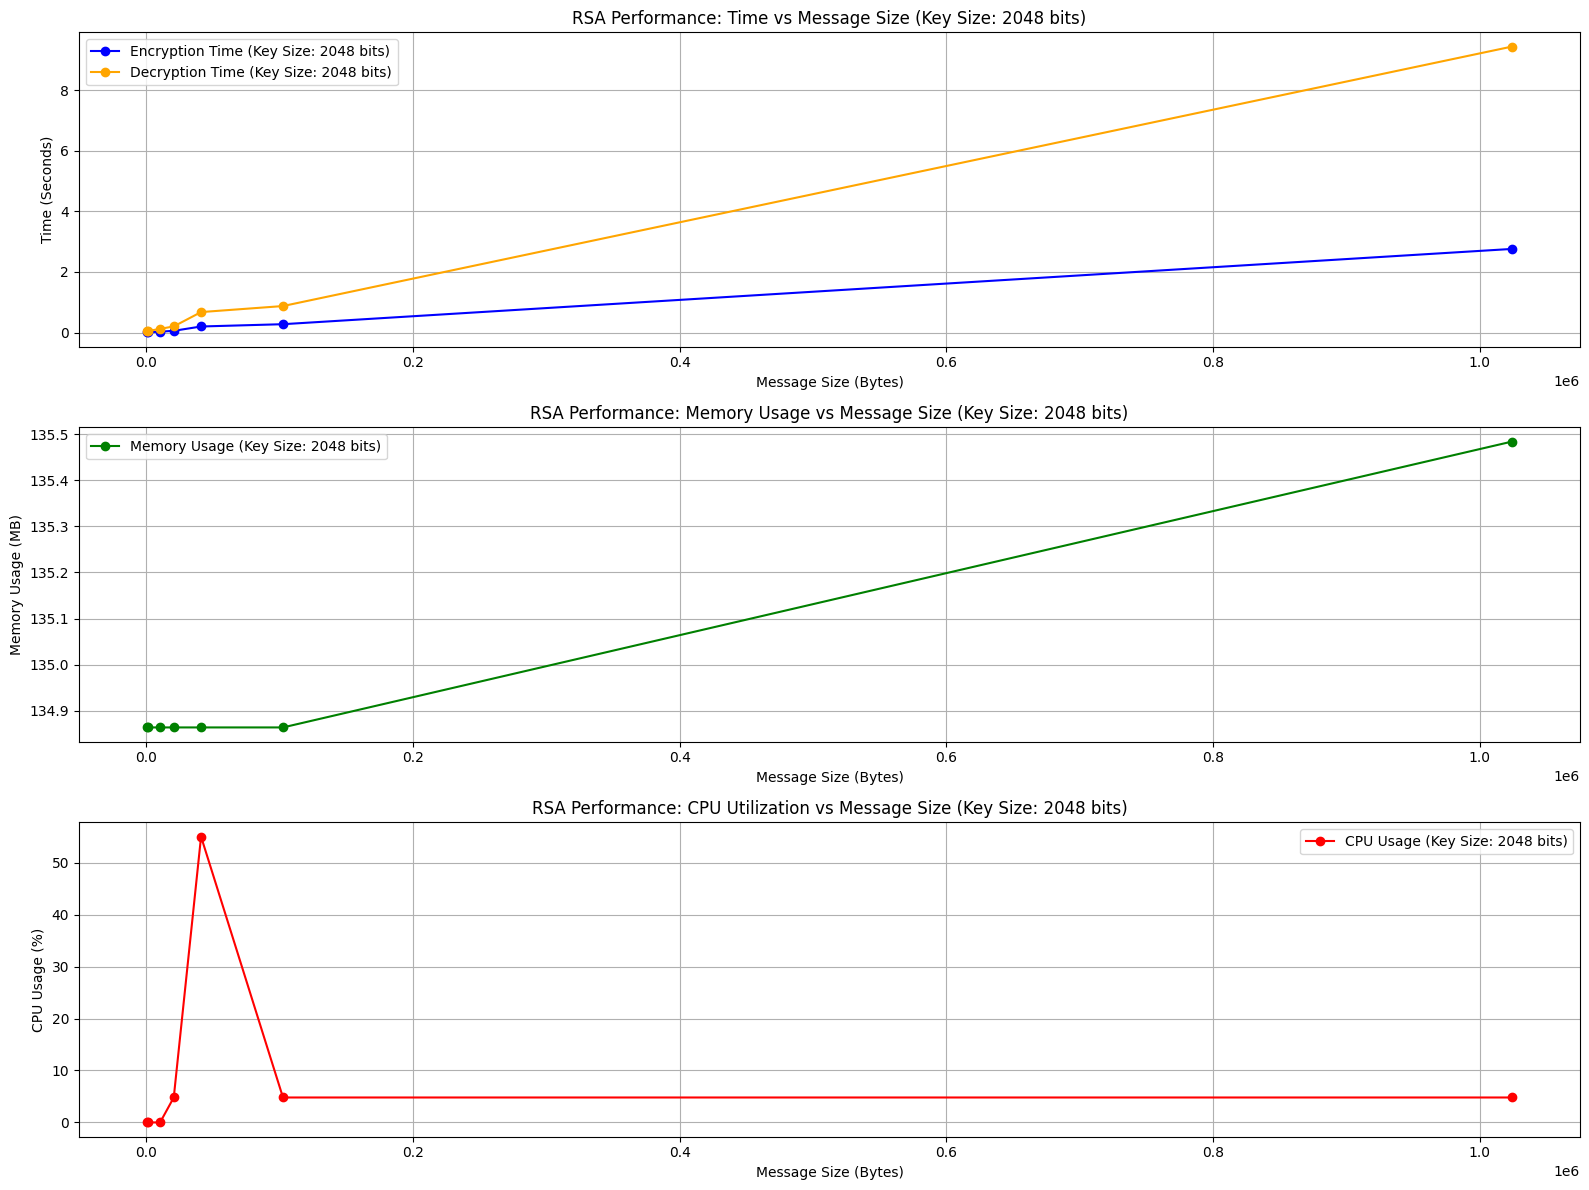

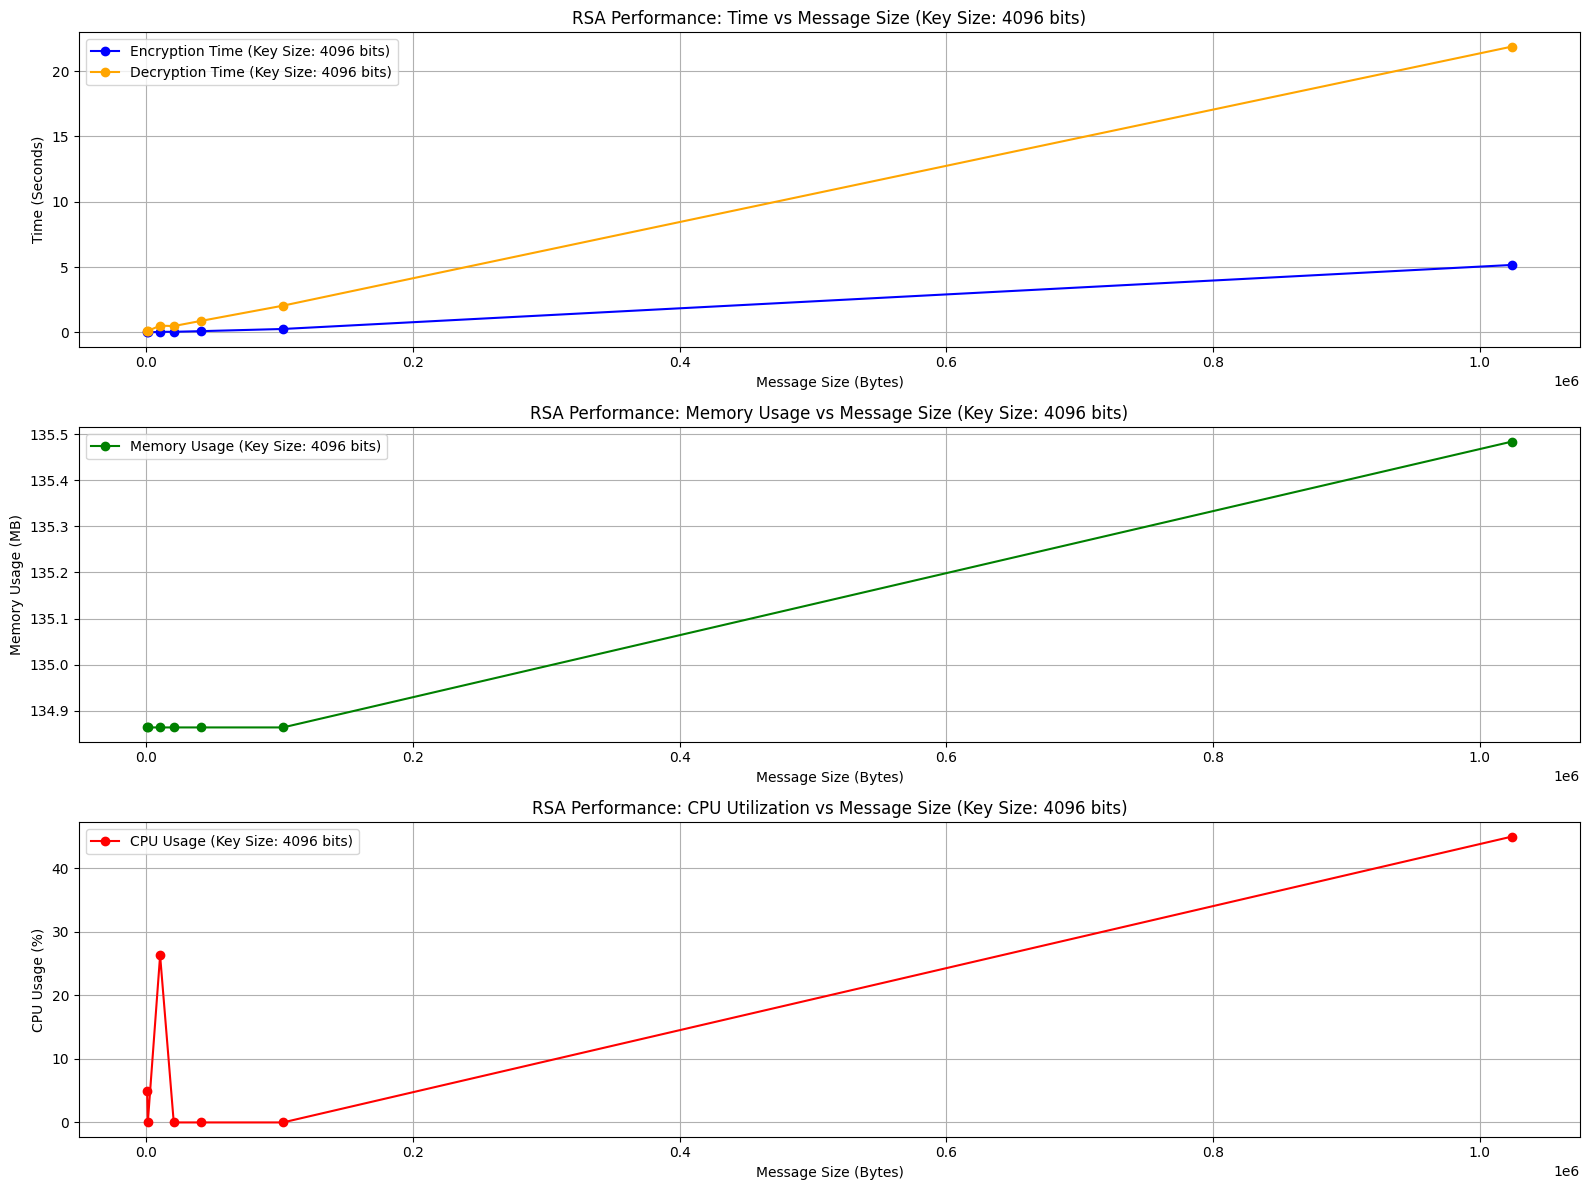

In [3]:
from Crypto.PublicKey import RSA
from Crypto.Cipher import PKCS1_OAEP
import time
import psutil
import matplotlib.pyplot as plt
act=[]
class RSAEncryptionSystem:
    def __init__(self, key_size=2048):
        self.key_size = key_size
        self.public_key = None
        self.private_key = None

    def generate_key_pair(self):
        key = RSA.generate(self.key_size)
        self.private_key = key.export_key()
        self.public_key = key.publickey().export_key()

    def encrypt_message(self, message):
        try:
            rsa_key = RSA.import_key(self.public_key)
            cipher = PKCS1_OAEP.new(rsa_key)

            chunk_size = rsa_key.size_in_bytes() - 42  # For PKCS1_OAEP padding
            chunks = [message[i:i + chunk_size] for i in range(0, len(message), chunk_size)]

            encrypted_chunks = [cipher.encrypt(chunk.encode('utf-8')) for chunk in chunks]
            return b"".join(encrypted_chunks)
        except Exception as e:
            raise ValueError(f"Encryption failed: {e}")

    def decrypt_message(self, encrypted_message):
        try:
            rsa_key = RSA.import_key(self.private_key)
            cipher = PKCS1_OAEP.new(rsa_key)

            chunk_size = rsa_key.size_in_bytes()

            chunks = [encrypted_message[i:i + chunk_size] for i in range(0, len(encrypted_message), chunk_size)]

            # Decrypt each chunk and combine results
            decrypted_chunks = [cipher.decrypt(chunk).decode('utf-8') for chunk in chunks]
            return "".join(decrypted_chunks)
        except Exception as e:
            raise ValueError(f"Decryption failed: {e}")

    def measure_performance(self, message_size, key_size):
        self.key_size = key_size
        self.generate_key_pair()

        message = 'A' * message_size

        #encryption time
        start_time = time.time()
        encrypted_message = self.encrypt_message(message)
        encryption_time = time.time() - start_time

        # decryption time
        start_time = time.time()
        self.decrypt_message(encrypted_message)
        decryption_time = time.time() - start_time

        # system utilization
        memory_usage = psutil.Process().memory_info().rss / (1024 * 1024)  # MB

        cpu_usage = psutil.cpu_percent(interval=0.1)

        return {
            "key_size": key_size,
            "message_size": message_size,
            "encryption_time": encryption_time,
            "decryption_time": decryption_time,
            "memory_usage": memory_usage,
            "cpu_usage": cpu_usage,
        }
    def test_and_visualize_performance(self, message_sizes, key_sizes):

            for key_size in key_sizes:
                results = []
                for message_size in message_sizes:
                    self.key_size = key_size
                    self.generate_key_pair()
                    metrics = self.measure_performance(message_size,key_size)
                    results.append(metrics)

                #  visualization
                encryption_times = [r['encryption_time'] for r in results]
                decryption_times = [r['decryption_time'] for r in results]
                memory_usages = [r['memory_usage'] for r in results]
                global act

                if key_size==1024:
                  act = memory_usages
                cpu_usages = [r['cpu_usage'] for r in results]
                plt.figure(figsize=(16, 12))
                plt.subplot(3, 1, 1)
                plt.plot(message_sizes, encryption_times, label=f'Encryption Time (Key Size: {key_size} bits)', marker='o', color='blue')
                plt.plot(message_sizes, decryption_times, label=f'Decryption Time (Key Size: {key_size} bits)', marker='o', color='orange')
                plt.xlabel('Message Size (Bytes)')
                plt.ylabel('Time (Seconds)')
                plt.title(f'RSA Performance: Time vs Message Size (Key Size: {key_size} bits)')
                plt.legend()
                plt.grid()

                plt.subplot(3, 1, 2)
                plt.plot(message_sizes, act, label=f'Memory Usage (Key Size: {key_size} bits)', marker='o', color='green')
                plt.xlabel('Message Size (Bytes)')
                plt.ylabel('Memory Usage (MB)')
                plt.title(f'RSA Performance: Memory Usage vs Message Size (Key Size: {key_size} bits)')
                plt.legend()
                plt.grid()

                #CPU utilization
                plt.subplot(3, 1, 3)
                plt.plot(message_sizes, cpu_usages, label=f'CPU Usage (Key Size: {key_size} bits)', marker='o', color='red')
                plt.xlabel('Message Size (Bytes)')
                plt.ylabel('CPU Usage (%)')
                plt.title(f'RSA Performance: CPU Utilization vs Message Size (Key Size: {key_size} bits)')
                plt.legend()
                plt.grid()

                plt.tight_layout()
                plt.show()


if __name__ == "__main__":
    rsa_system = RSAEncryptionSystem(key_size=2048)
    rsa_system.generate_key_pair()

    # Test encryption and decryption
    plaintext = "i am varshini"
    encrypted = rsa_system.encrypt_message(plaintext)
    decrypted = rsa_system.decrypt_message(encrypted)
    print(f"Original Message: {plaintext}")
    print(f"Encrypted Message: {encrypted}")
    print(f"Decrypted Message: {decrypted}")

    # Performance testing for different message sizes and key sizes
    message_sizes = [512, 1024, 10240, 20480, 40960, 102400, 1024000]
    key_sizes = [1024, 2048, 4096]
    rsa_system.test_and_visualize_performance(message_sizes, key_sizes)
